In [1]:
import matplotlib.pyplot as plt
import math
import numpy as np

# Q1

In [5]:
data=[
    ["Sunny",85,85,"Weak","No"],
    ["Sunny",80,90,"Strong","No"],
    ["Overcast",83,78,"Weak","Yes"],
    ["Rain",70,96,"Weak","Yes"],
    ["Rain",68,80,"Weak","Yes"],
    ["Rain",65,70,"Strong","No"],
    ["Overcast",64,65,"Strong","Yes"],
    ["Sunny",72,95,"Weak","No"],
    ["Sunny",69,70,"Weak","Yes"],
    ["Rain",75,80,"Weak","Yes"],
    ["Sunny",75,70,"Strong","Yes"],
    ["Overcast",72,90,"Strong","Yes"],
    ["Overcast",81,75,"Weak","Yes"],
    ["Rain",71,80,"Strong","No"]
]

yes=0
no=0

for row in data:
    if row[4]=="Yes":
        yes+=1
    else:
        no+=1

p_yes=yes/len(data)
p_no=no/len(data)

entropy=0

if p_yes>0:
    entropy-=p_yes*math.log2(p_yes)

if p_no>0:
    entropy-=p_no*math.log2(p_no)

print("Total Entropy:",entropy)


sunny=[row for row in data if row[0]=="Sunny"]
overcast=[row for row in data if row[0]=="Overcast"]
rain=[row for row in data if row[0]=="Rain"]

sunny_yes=sum(row[4]=="Yes" for row in sunny)
sunny_no=sum(row[4]=="No" for row in sunny)

overcast_yes=sum(row[4]=="Yes" for row in overcast)
overcast_no=sum(row[4]=="No" for row in overcast)

rain_yes=sum(row[4]=="Yes" for row in rain)
rain_no=sum(row[4]=="No" for row in rain)


sunny_entropy=0

if sunny_yes>0:
    p=sunny_yes/len(sunny)
    sunny_entropy-=p*math.log2(p)

if sunny_no>0:
    p=sunny_no/len(sunny)
    sunny_entropy-=p*math.log2(p)


overcast_entropy=0

if overcast_yes>0:
    p=overcast_yes/len(overcast)
    overcast_entropy-=p*math.log2(p)

if overcast_no>0:
    p=overcast_no/len(overcast)
    overcast_entropy-=p*math.log2(p)


rain_entropy=0

if rain_yes>0:
    p=rain_yes/len(rain)
    rain_entropy-=p*math.log2(p)

if rain_no>0:
    p=rain_no/len(rain)
    rain_entropy-=p*math.log2(p)


weighted_entropy=(
    len(sunny)/len(data)*sunny_entropy+
    len(overcast)/len(data)*overcast_entropy+
    len(rain)/len(data)*rain_entropy
)

ig_outlook=entropy-weighted_entropy

split_info=0

for size in [len(sunny),len(overcast),len(rain)]:
    p=size/len(data)
    split_info-=p*math.log2(p)

gr_outlook=ig_outlook/split_info

print("Gain Ratio - Outlook:",gr_outlook)



weak=[row for row in data if row[3]=="Weak"]
strong=[row for row in data if row[3]=="Strong"]

weak_yes=sum(row[4]=="Yes" for row in weak)
weak_no=sum(row[4]=="No" for row in weak)

strong_yes=sum(row[4]=="Yes" for row in strong)
strong_no=sum(row[4]=="No" for row in strong)


weak_entropy=0

if weak_yes>0:
    p=weak_yes/len(weak)
    weak_entropy-=p*math.log2(p)

if weak_no>0:
    p=weak_no/len(weak)
    weak_entropy-=p*math.log2(p)


strong_entropy=0

if strong_yes>0:
    p=strong_yes/len(strong)
    strong_entropy-=p*math.log2(p)

if strong_no>0:
    p=strong_no/len(strong)
    strong_entropy-=p*math.log2(p)


weighted_entropy=(
    len(weak)/len(data)*weak_entropy+
    len(strong)/len(data)*strong_entropy
)

ig_wind=entropy-weighted_entropy

split_info=0

for size in [len(weak),len(strong)]:
    p=size/len(data)
    split_info-=p*math.log2(p)

gr_wind=ig_wind/split_info

print("Gain Ratio - Wind:",gr_wind)

Total Entropy: 0.9402859586706311
Gain Ratio - Outlook: 0.15642756242117528
Gain Ratio - Wind: 0.048848615511520824


# Q2

In [7]:
yes=0
no=0

for row in data:
    if row[4]=="Yes":
        yes+=1
    else:
        no+=1

p_yes=yes/len(data)
p_no=no/len(data)

gini=1-p_yes**2-p_no**2

print("Initial Gini:",gini)


overcast=[]
other=[]

for row in data:
    if row[0]=="Overcast":
        overcast.append(row)
    else:
        other.append(row)

overcast_yes=0
overcast_no=0

for row in overcast:
    if row[4]=="Yes":
        overcast_yes+=1
    else:
        overcast_no+=1

p_yes=overcast_yes/len(overcast)
p_no=overcast_no/len(overcast)

gini_overcast=1-p_yes**2-p_no**2


other_yes=0
other_no=0

for row in other:
    if row[4]=="Yes":
        other_yes+=1
    else:
        other_no+=1

p_yes=other_yes/len(other)
p_no=other_no/len(other)

gini_other=1-p_yes**2-p_no**2

weighted_gini=(
    len(overcast)/len(data)*gini_overcast+
    len(other)/len(data)*gini_other
)

print("Gini Outlook:",weighted_gini)


left=[]
right=[]

for row in other:
    if row[1]<=77.5:
        left.append(row)
    else:
        right.append(row)

left_yes=0
left_no=0

for row in left:
    if row[4]=="Yes":
        left_yes+=1
    else:
        left_no+=1

p_yes=left_yes/len(left)
p_no=left_no/len(left)

gini_left=1-p_yes**2-p_no**2


right_yes=0
right_no=0

for row in right:
    if row[4]=="Yes":
        right_yes+=1
    else:
        right_no+=1

p_yes=right_yes/len(right)
p_no=right_no/len(right)

gini_right=1-p_yes**2-p_no**2

weighted_gini=(
    len(left)/len(other)*gini_left+
    len(right)/len(other)*gini_right
)

print("Gini Temperature:",weighted_gini)


left1=[]
right1=[]

for row in left:
    if row[1]<=66.5:
        left1.append(row)
    else:
        right1.append(row)

yes1=0
no1=0

for row in left1:
    if row[4]=="Yes":
        yes1+=1
    else:
        no1+=1

p_yes=yes1/len(left1)
p_no=no1/len(left1)

gini1=1-p_yes**2-p_no**2


yes2=0
no2=0

for row in right1:
    if row[4]=="Yes":
        yes2+=1
    else:
        no2+=1

p_yes=yes2/len(right1)
p_no=no2/len(right1)

gini2=1-p_yes**2-p_no**2

weighted_gini=(
    len(left1)/len(left)*gini1+
    len(right1)/len(left)*gini2
)

print("Gini Temperature <= 66.5:",weighted_gini)


new_sample=["Sunny",72,90,"Weak"]

if new_sample[0]=="Overcast":
    result="Yes"
else:
    if new_sample[1]<=66.5:
        result="No"
    elif new_sample[1]<=70.5:
        result="Yes"
    elif new_sample[1]<=73.5:
        result="No"
    elif new_sample[1]<=77.5:
        result="Yes"
    else:
        result="No"

print("Predicted Decision:",result)

Initial Gini: 0.4591836734693877
Gini Outlook: 0.35714285714285715
Gini Temperature: 0.375
Gini Temperature <= 66.5: 0.35714285714285715
Predicted Decision: No


# Q3

In [8]:
import math

data3=[
    ["Low","Good","Yes"],
    ["Low","Bad","No"],
    ["Medium","Good","Yes"],
    ["Medium","Bad","Yes"],
    ["High","Good","Yes"],
    ["High","Bad","No"]
]

yes=0
no=0

for row in data3:
    if row[2]=="Yes":
        yes+=1
    else:
        no+=1

p_yes=yes/len(data3)
p_no=no/len(data3)

entropy=0

if p_yes>0:
    entropy-=p_yes*math.log2(p_yes)

if p_no>0:
    entropy-=p_no*math.log2(p_no)

print("Initial Entropy:",entropy)


good=[]
bad=[]

for row in data3:
    if row[1]=="Good":
        good.append(row)
    else:
        bad.append(row)

good_yes=0
good_no=0

for row in good:
    if row[2]=="Yes":
        good_yes+=1
    else:
        good_no+=1

good_entropy=0

if good_yes>0:
    p=good_yes/len(good)
    good_entropy-=p*math.log2(p)

if good_no>0:
    p=good_no/len(good)
    good_entropy-=p*math.log2(p)


bad_yes=0
bad_no=0

for row in bad:
    if row[2]=="Yes":
        bad_yes+=1
    else:
        bad_no+=1

bad_entropy=0

if bad_yes>0:
    p=bad_yes/len(bad)
    bad_entropy-=p*math.log2(p)

if bad_no>0:
    p=bad_no/len(bad)
    bad_entropy-=p*math.log2(p)


weighted_entropy=(
    len(good)/len(data3)*good_entropy+
    len(bad)/len(data3)*bad_entropy
)

ig_credit=entropy-weighted_entropy

split_info=0

for size in [len(good),len(bad)]:
    p=size/len(data3)
    split_info-=p*math.log2(p)

gr_credit=ig_credit/split_info

print("Information Gain - Credit:",ig_credit)
print("Gain Ratio - Credit:",gr_credit)


low=[]
medium=[]
high=[]

for row in data3:
    if row[0]=="Low":
        low.append(row)
    elif row[0]=="Medium":
        medium.append(row)
    else:
        high.append(row)


low_yes=sum(row[2]=="Yes" for row in low)
low_no=sum(row[2]=="No" for row in low)

medium_yes=sum(row[2]=="Yes" for row in medium)
medium_no=sum(row[2]=="No" for row in medium)

high_yes=sum(row[2]=="Yes" for row in high)
high_no=sum(row[2]=="No" for row in high)


low_entropy=0

if low_yes>0:
    p=low_yes/len(low)
    low_entropy-=p*math.log2(p)

if low_no>0:
    p=low_no/len(low)
    low_entropy-=p*math.log2(p)


medium_entropy=0

if medium_yes>0:
    p=medium_yes/len(medium)
    medium_entropy-=p*math.log2(p)

if medium_no>0:
    p=medium_no/len(medium)
    medium_entropy-=p*math.log2(p)


high_entropy=0

if high_yes>0:
    p=high_yes/len(high)
    high_entropy-=p*math.log2(p)

if high_no>0:
    p=high_no/len(high)
    high_entropy-=p*math.log2(p)


weighted_entropy=(
    len(low)/len(data3)*low_entropy+
    len(medium)/len(data3)*medium_entropy+
    len(high)/len(data3)*high_entropy
)

ig_income=entropy-weighted_entropy

split_info=0

for size in [len(low),len(medium),len(high)]:
    p=size/len(data3)
    split_info-=p*math.log2(p)

gr_income=ig_income/split_info

print("Information Gain - Income:",ig_income)
print("Gain Ratio - Income:",gr_income)


yes=0
no=0

for row in data3:
    if row[2]=="Yes":
        yes+=1
    else:
        no+=1

p_yes=yes/len(data3)
p_no=no/len(data3)

gini=1-p_yes**2-p_no**2

print("Initial Gini:",gini)


good_yes=sum(row[2]=="Yes" for row in good)
good_no=sum(row[2]=="No" for row in good)

bad_yes=sum(row[2]=="Yes" for row in bad)
bad_no=sum(row[2]=="No" for row in bad)

gini_good=1-(good_yes/len(good))**2-(good_no/len(good))**2
gini_bad=1-(bad_yes/len(bad))**2-(bad_no/len(bad))**2

weighted_gini_credit=(
    len(good)/len(data3)*gini_good+
    len(bad)/len(data3)*gini_bad
)

print("Weighted Gini - Credit:",weighted_gini_credit)


gini_low=1-(low_yes/len(low))**2-(low_no/len(low))**2
gini_medium=1-(medium_yes/len(medium))**2-(medium_no/len(medium))**2
gini_high=1-(high_yes/len(high))**2-(high_no/len(high))**2

weighted_gini_income=(
    len(low)/len(data3)*gini_low+
    len(medium)/len(data3)*gini_medium+
    len(high)/len(data3)*gini_high
)

print("Weighted Gini - Income:",weighted_gini_income)


new_sample=["Medium","Bad"]

if new_sample[1]=="Good":
    result="Yes"
else:
    if new_sample[0]=="Low":
        result="No"
    elif new_sample[0]=="Medium":
        result="Yes"
    else:
        result="No"

print("New Sample:",new_sample)
print("C4.5 Prediction:",result)
print("CART Prediction:",result)

Initial Entropy: 0.9182958340544896
Information Gain - Credit: 0.4591479170272448
Gain Ratio - Credit: 0.4591479170272448
Information Gain - Income: 0.2516291673878229
Gain Ratio - Income: 0.15876032857139014
Initial Gini: 0.4444444444444445
Weighted Gini - Credit: 0.2222222222222222
Weighted Gini - Income: 0.3333333333333333
New Sample: ['Medium', 'Bad']
C4.5 Prediction: Yes
CART Prediction: Yes


# Additional Q1

Predicted Decision: No


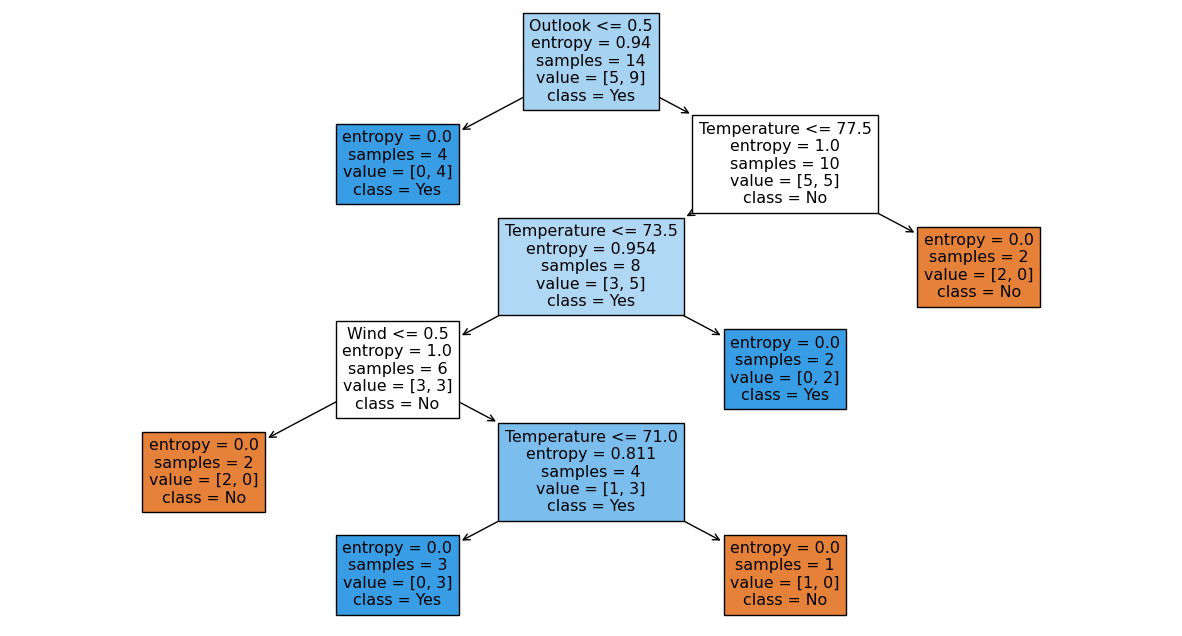

In [9]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

X=[
    ["Sunny",85,85,"Weak"],
    ["Sunny",80,90,"Strong"],
    ["Overcast",83,78,"Weak"],
    ["Rain",70,96,"Weak"],
    ["Rain",68,80,"Weak"],
    ["Rain",65,70,"Strong"],
    ["Overcast",64,65,"Strong"],
    ["Sunny",72,95,"Weak"],
    ["Sunny",69,70,"Weak"],
    ["Rain",75,80,"Weak"],
    ["Sunny",75,70,"Strong"],
    ["Overcast",72,90,"Strong"],
    ["Overcast",81,75,"Weak"],
    ["Rain",71,80,"Strong"]
]

y=[
    "No",
    "No",
    "Yes",
    "Yes",
    "Yes",
    "No",
    "Yes",
    "No",
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "Yes",
    "No"
]

le_outlook=LabelEncoder()
le_wind=LabelEncoder()
le_y=LabelEncoder()

outlook=le_outlook.fit_transform([row[0] for row in X])
wind=le_wind.fit_transform([row[3] for row in X])
target=le_y.fit_transform(y)

X_encoded=[]

for i in range(len(X)):
    X_encoded.append([
        outlook[i],
        X[i][1],
        X[i][2],
        wind[i]
    ])

model=DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

model.fit(X_encoded,target)

new_sample=[
    le_outlook.transform(["Sunny"])[0],
    72,
    90,
    le_wind.transform(["Weak"])[0]
]

prediction=model.predict([new_sample])

print("Predicted Decision:",le_y.inverse_transform(prediction)[0])

plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=["Outlook","Temperature","Humidity","Wind"],
    class_names=le_y.classes_,
    filled=True
)

plt.show()

# Additional Q2

Predicted Decision: No


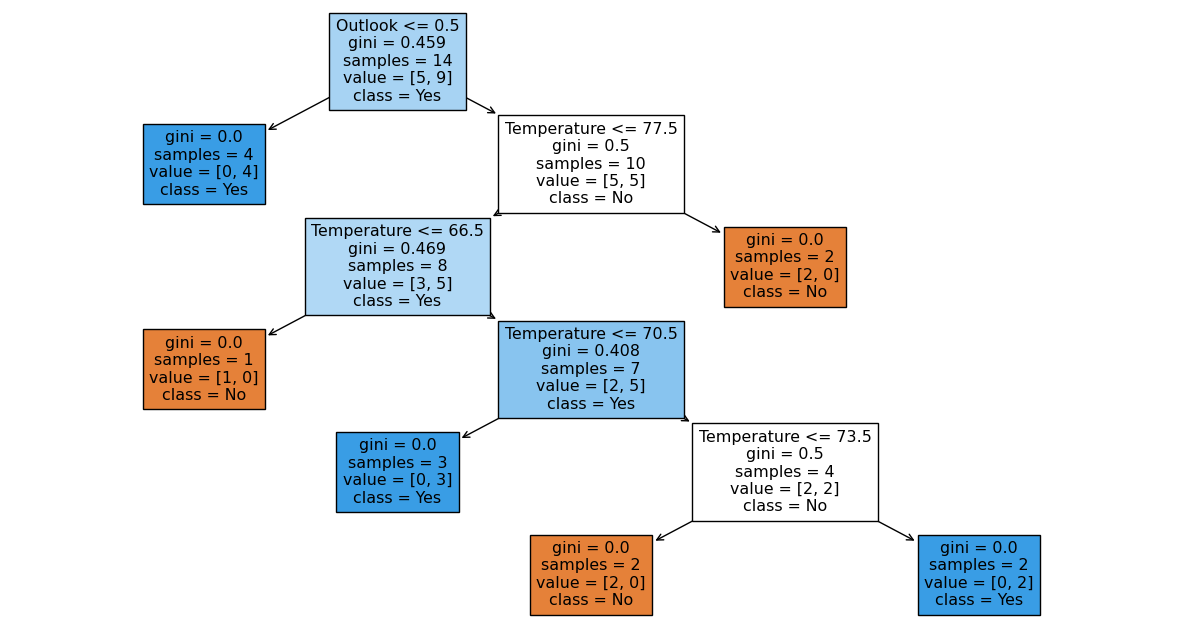

In [10]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

model_cart=DecisionTreeClassifier(
    criterion="gini",
    random_state=0
)

model_cart.fit(X_encoded,target)

new_sample=[
    le_outlook.transform(["Sunny"])[0],
    72,
    90,
    le_wind.transform(["Weak"])[0]
]

prediction=model_cart.predict([new_sample])

print("Predicted Decision:",le_y.inverse_transform(prediction)[0])

plt.figure(figsize=(15,8))

plot_tree(
    model_cart,
    feature_names=["Outlook","Temperature","Humidity","Wind"],
    class_names=le_y.classes_,
    filled=True
)

plt.show()